# RAG Sufficient Context: Selective Generation Pipeline

**Explaining and Reducing Hallucinations in RAG via Sufficient Context**

Inspired by: *Sufficient Context: A New Lens on Systems Retrieval Augmented Generation* (ICLR 2025)

Authors: Aleksandr Gavkovskii, Ilya Maksimov, Karim Zakirov

---

This notebook runs the full pipeline end-to-end:
1. Setup & install dependencies
2. Load HotPotQA dataset
3. BM25 retrieval & context construction
4. LLM generation (LLaMA-3.1-8B-Instruct)
5. Evaluation (EM/F1, categorization)
6. Sufficient context autorater
7. Selective generation gate
8. Visualization & analysis

## 1. Setup

In [13]:
!git pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 879 bytes | 439.00 KiB/s, done.
From https://github.com/SachaYT1/rag-sufficient-context
   af9baa1..f36e25c  main       -> origin/main
Updating af9baa1..f36e25c
Fast-forward
 configs/default.yaml          | 2 +-
 notebooks/main_pipeline.ipynb | 9 ++++++++-
 2 files changed, 9 insertions(+), 2 deletions(-)


In [ ]:
# Clone the repository and install dependencies
!git clone https://github.com/SachaYT1/rag-sufficient-context.git
%cd rag-sufficient-context
!pip install -q -r requirements.txt

In [14]:
# HuggingFace login (required for LLaMA-3.1-8B, a gated model)
# 1. Go to https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct and accept the license
# 2. Create a READ token at https://huggingface.co/settings/tokens
# 3. Paste it below when prompted
from huggingface_hub import login
login()

In [15]:
# Imports
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

from src.utils import load_config, cache_results, load_cached
from src.retrieval import load_hotpotqa, build_retrieval_pipeline
from src.generation import load_model, generate_answers_batch
from src.evaluation import evaluate_all, categorize_response
from src.autorater import rate_all_examples
from src.confidence import estimate_confidence_batch
from src.gate import (
    prepare_features, train_gate,
    compute_selective_curves, plot_accuracy_coverage,
    plot_sufficiency_breakdown,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [16]:
# Load configuration
config = load_config("configs/default.yaml")
pprint(config)

{'autorater': {'aggregation': 'or', 'chunk_size_tokens': 1400},
 'confidence': {'method': 'p_correct'},
 'dataset': {'name': 'hotpotqa',
             'num_examples': 500,
             'seed': 42,
             'split': 'validation'},
 'gate': {'model': 'logistic_regression', 'threshold_steps': 50},
 'generation': {'max_new_tokens': 256,
                'model': 'mistralai/Mistral-7B-Instruct-v0.3',
                'temperature': 0.0},
 'retrieval': {'max_context_tokens': 4096, 'method': 'bm25', 'top_k': 5}}


## 2. Load Dataset

In [17]:
# Load HotPotQA dev subset
examples = load_hotpotqa(
    split=config["dataset"]["split"],
    num_examples=config["dataset"]["num_examples"],
    seed=config["dataset"]["seed"],
)
print(f"Loaded {len(examples)} examples")
print(f"\nExample:")
print(f"  Question: {examples[0]['question']}")
print(f"  Answer: {examples[0]['answer']}")
print(f"  Type: {examples[0]['type']}")
print(f"  Num passages: {len(examples[0]['passages'])}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 500 examples

Example:
  Question: What nationality was Oliver Reed's character in the film Royal Flash?
  Answer: Prussian
  Type: bridge
  Num passages: 10


## 3. BM25 Retrieval & Context Construction

In [18]:
# Check for cached retrieval results
retrieval_cache = "data/retrieval_results.json"
cached = load_cached(retrieval_cache)

if cached is not None:
    examples_with_context = cached
    print(f"Loaded {len(examples_with_context)} cached retrieval results")
else:
    # Load tokenizer for truncation
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(config["generation"]["model"])

    examples_with_context = build_retrieval_pipeline(
        examples,
        top_k=config["retrieval"]["top_k"],
        max_context_tokens=config["retrieval"]["max_context_tokens"],
        tokenizer=tokenizer,
    )
    cache_results(examples_with_context, retrieval_cache)
    print(f"Retrieved contexts for {len(examples_with_context)} examples (cached)")

# Show example context
print(f"\nContext length (chars): {len(examples_with_context[0]['context'])}")
print(f"Context preview: {examples_with_context[0]['context'][:300]}...")

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Retrieving contexts: 100%|██████████| 500/500 [00:01<00:00, 267.84it/s]


Retrieved contexts for 500 examples (cached)

Context length (chars): 1932
Context preview: Ivan Dragomiloff: Ivan Dragomiloff is a fictional character, the chairman of "The Assassination Bureau, Ltd" in the book of that name by Jack London.  The character was played by actor Oliver Reed in the film of the same name.

Royal Flash (film): Royal Flash is a 1975 film based on George MacDonald...


## 4. LLM Generation

In [19]:
# Load model
model, tokenizer = load_model(
    model_name=config["generation"]["model"],
    device="auto",
)
print(f"Model loaded: {config['generation']['model']}")
print(f"Device: {next(model.parameters()).device}")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded: mistralai/Mistral-7B-Instruct-v0.3
Device: cuda:0


In [20]:
# Generate answers
generation_cache = "data/generation_results.json"
cached = load_cached(generation_cache)

if cached is not None:
    examples_with_answers = cached
    print(f"Loaded {len(examples_with_answers)} cached generation results")
else:
    examples_with_answers = generate_answers_batch(
        examples_with_context,
        model, tokenizer,
        max_new_tokens=config["generation"]["max_new_tokens"],
        temperature=config["generation"]["temperature"],
    )
    cache_results(examples_with_answers, generation_cache)
    print(f"Generated answers for {len(examples_with_answers)} examples (cached)")

# Show example
ex = examples_with_answers[0]
print(f"\nQuestion: {ex['question']}")
print(f"Gold answer: {ex['answer']}")
print(f"Prediction: {ex['prediction']}")
print(f"Confidence: {ex['confidence']:.3f}")

Generating answers: 100%|██████████| 500/500 [1:17:30<00:00,  9.30s/it]

Generated answers for 500 examples (cached)

Question: What nationality was Oliver Reed's character in the film Royal Flash?
Gold answer: Prussian
Prediction: Otto von Bismarck, the character played by Oliver Reed in the film Royal Flash, was German.
Confidence: 1.000


## 5. Evaluation

In [21]:
# Evaluate all examples
eval_results = evaluate_all(examples_with_answers)
metrics = eval_results["metrics"]

print("=" * 50)
print("BASELINE EVALUATION RESULTS")
print("=" * 50)
print(f"Total examples: {metrics['total']}")
print(f"\nCategories:")
print(f"  Correct:      {metrics['correct']:>4d} ({metrics['correct_rate']:.1%})")
print(f"  Abstain:      {metrics['abstain']:>4d} ({metrics['abstain_rate']:.1%})")
print(f"  Hallucinate:  {metrics['hallucinate']:>4d} ({metrics['hallucinate_rate']:.1%})")
print(f"\nMetrics:")
print(f"  Mean EM: {metrics['mean_em']:.3f}")
print(f"  Mean F1: {metrics['mean_f1']:.3f}")

BASELINE EVALUATION RESULTS
Total examples: 500

Categories:
  Correct:       201 (40.2%)
  Abstain:       135 (27.0%)
  Hallucinate:   164 (32.8%)

Metrics:
  Mean EM: 0.312
  Mean F1: 0.405


In [22]:
# Add category labels to examples
for ex, per_ex in zip(examples_with_answers, eval_results["per_example"]):
    ex["category"] = per_ex["category"]
    ex["em"] = per_ex["em"]
    ex["f1"] = per_ex["f1"]

## 6. Sufficient Context Autorater

In [23]:
# Rate context sufficiency
autorater_cache = "data/autorater_results.json"
cached = load_cached(autorater_cache)

if cached is not None:
    examples_with_sufficiency = cached
    print(f"Loaded {len(examples_with_sufficiency)} cached autorater results")
else:
    examples_with_sufficiency = rate_all_examples(
        examples_with_answers,
        model, tokenizer,
        chunk_size_tokens=config["autorater"]["chunk_size_tokens"],
        aggregation=config["autorater"]["aggregation"],
    )
    cache_results(examples_with_sufficiency, autorater_cache)
    print(f"Rated sufficiency for {len(examples_with_sufficiency)} examples (cached)")

# Summary
n_sufficient = sum(1 for ex in examples_with_sufficiency if ex.get("sufficient"))
n_total = len(examples_with_sufficiency)
print(f"\nSufficient: {n_sufficient}/{n_total} ({n_sufficient/n_total:.1%})")
print(f"Insufficient: {n_total - n_sufficient}/{n_total} ({(n_total - n_sufficient)/n_total:.1%})")

Rating context sufficiency: 100%|██████████| 500/500 [29:41<00:00,  3.56s/it]

Rated sufficiency for 500 examples (cached)

Sufficient: 348/500 (69.6%)
Insufficient: 152/500 (30.4%)


## 7. Selective Generation Gate

In [24]:
# Prepare features and train gate
X, y = prepare_features(examples_with_sufficiency)
print(f"Training data: {X.shape[0]} examples (excluding abstentions)")
print(f"Positive (correct): {y.sum():.0f}, Negative (hallucinate): {(1-y).sum():.0f}")

# Train logistic regression gate
gate = train_gate(X, y)
print(f"\nGate coefficients:")
print(f"  confidence weight: {gate.coef_[0][0]:.3f}")
print(f"  sufficiency weight: {gate.coef_[0][1]:.3f}")
print(f"  intercept: {gate.intercept_[0]:.3f}")

Training data: 365 examples (excluding abstentions)
Positive (correct): 201, Negative (hallucinate): 164

Gate coefficients:
  confidence weight: 0.224
  sufficiency weight: 0.645
  intercept: -0.577


In [25]:
# Compute selective accuracy-coverage curves
curves = compute_selective_curves(
    examples_with_sufficiency,
    gate=gate,
    threshold_steps=config["gate"]["threshold_steps"],
)

# Save curves
cache_results(curves, "results/selective_curves.json")
print("Curves computed and saved")

Curves computed and saved


## 8. Visualization & Analysis

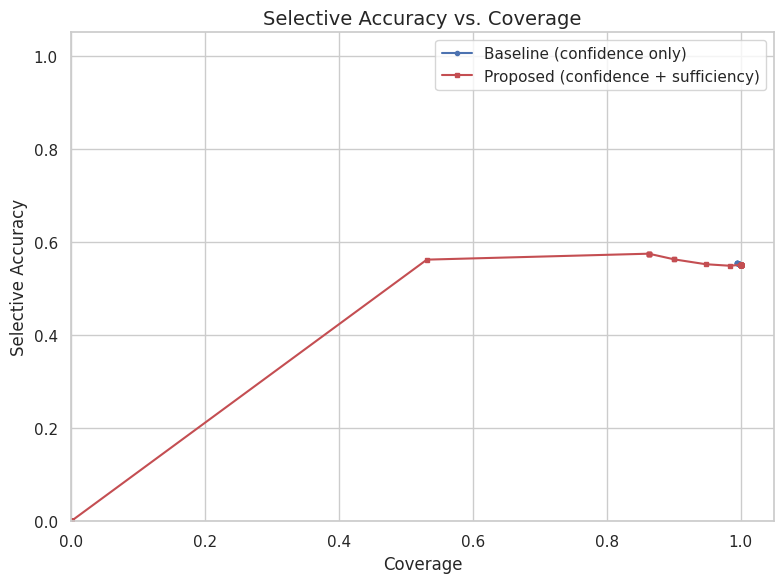

In [26]:
# Plot 1: Selective Accuracy vs. Coverage
plot_accuracy_coverage(curves, save_path="results/accuracy_coverage.png")

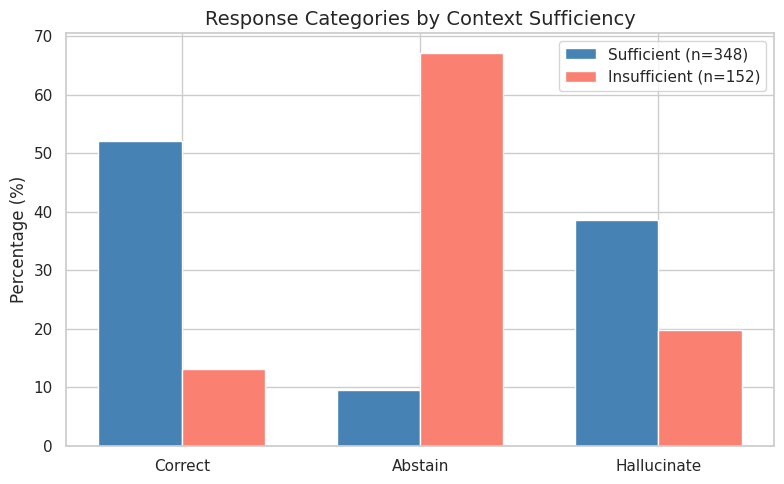

In [27]:
# Plot 2: Sufficiency breakdown
plot_sufficiency_breakdown(examples_with_sufficiency, save_path="results/sufficiency_breakdown.png")

In [28]:
# Summary table
import pandas as pd

# Create summary dataframe
summary_data = []
for ex in examples_with_sufficiency:
    summary_data.append({
        "question": ex["question"][:80],
        "category": ex.get("category", "unknown"),
        "sufficient": ex.get("sufficient", False),
        "confidence": ex.get("confidence", 0.0),
        "em": ex.get("em", 0.0),
        "f1": ex.get("f1", 0.0),
    })

df = pd.DataFrame(summary_data)

# Cross-tabulation
print("Category breakdown by sufficiency:")
print(pd.crosstab(df["sufficient"], df["category"], margins=True))
print()

# Mean confidence by category
print("Mean confidence by category:")
print(df.groupby("category")["confidence"].mean().round(3))

Category breakdown by sufficiency:
category    abstain  correct  hallucinate  All
sufficient                                    
False           102       20           30  152
True             33      181          134  348
All             135      201          164  500

Mean confidence by category:
category
abstain        0.019
correct        1.000
hallucinate    0.998
Name: confidence, dtype: float64


In [29]:
# Save all results
final_results = {
    "metrics": metrics,
    "n_sufficient": n_sufficient,
    "n_insufficient": n_total - n_sufficient,
    "gate_coefficients": {
        "confidence_weight": float(gate.coef_[0][0]),
        "sufficiency_weight": float(gate.coef_[0][1]),
        "intercept": float(gate.intercept_[0]),
    },
}
cache_results(final_results, "results/final_metrics.json")
print("All results saved to results/")
print("\nDone! Pipeline complete.")

All results saved to results/

Done! Pipeline complete.
